# EVASPA tiling 

### Imports

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [14]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    raise Exception("Variable EVASPA_TEST_DATA_PATH must be set")
if os.environ["MNT_PATH"] is None:
    raise Exception("Variable MNT_PATH must be set")

In [15]:
import evaspa.api as api
import evaspa.tiling as tiling

### Read ROI and generate list of tiles

In [16]:
roi_tiles, adjs = api.generate_tiles(Path("../tests/data/roi_italy.gpkg"))

24-11-12 16:21:04 :: INFO :: Number of tiles = 77


In [17]:
roi_tiles.head()

,id,epsg,geometry,roi_coverage,land
1,31TFJ,32631,"POLYGON ((4.25248 44.24655, 4.25248 44.24655, ...",66.374863,88.166574
2,31TFK,32631,"POLYGON ((4.27204 45.14675, 4.27204 45.14675, ...",71.116867,100.000000
3,31TFL,32631,"POLYGON ((4.29253 46.04627, 4.29253 46.04627, ...",65.478102,100.000000
4,31TFM,32631,"POLYGON ((4.31404 46.94617, 4.31404 46.94617, ...",60.107835,100.000000
5,31TFN,32631,"POLYGON ((4.33660 47.84592, 4.33660 47.84592, ...",31.850051,100.000000


In [18]:
print(f"Number of tiles: {len(roi_tiles)}")

Number of tiles: 77


#### Plot

<Axes: title={'center': 'Percentage of land per tile'}>

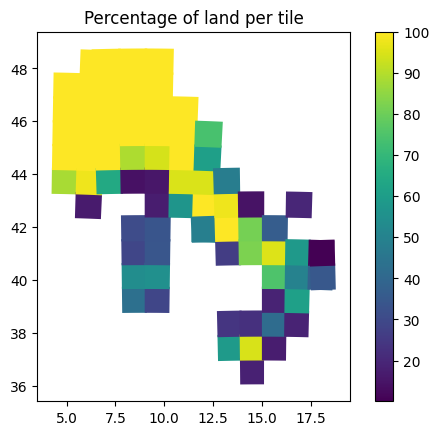

In [19]:
ax = plt.gca()
ax.set_title("Percentage of land per tile")
roi_tiles.plot(ax=ax, column="land", cmap="viridis", legend=True)

### Regroup tiles

In [20]:
group = api.regroup_tiles(roi_tiles, adjs, threshold=600000)

24-11-12 16:22:28 :: INFO :: Number of groups = 64
24-11-12 16:22:28 :: INFO :: Group size : 1 - Number : 54
24-11-12 16:22:28 :: INFO :: Group size : 2 - Number : 8
24-11-12 16:22:28 :: INFO :: Group size : 3 - Number : 1
24-11-12 16:22:28 :: INFO :: Group size : 4 - Number : 1


In [21]:
group.head()

,pvalid,nbvalid,zones,group_size
group,,,,
31TFJ,0.805275,2696787,"MULTIPOLYGON (((681360 4900020, 684420 4897800...",1
31TFK,0.641465,2148201,"MULTIPOLYGON (((624660 5000040, 624300 4999440...",1
31TFL,0.853785,2859240,"MULTIPOLYGON (((695040 5100000, 695580 5099220...",1
31TFM,0.966433,3236488,"MULTIPOLYGON (((699720 5107740, 699720 5107440...",1
31TFN,1.000000,3348900,"MULTIPOLYGON (((600000 5300040, 600000 5190240...",1


In [22]:
tiling.write_regroup(group.reset_index())